#Génération d'arbres et d'AB (Arbre Binaire)
Les codes concerne la génération d'arbres et d'AB. Le même GAN est utilisé dans tous les cas. Ce sont les datasets qui sont différents, ils comptent :
- Pour les arbres : Un dataset généré aléatoirement avec tous les arbres non-isomorphes entre-eux apparaissant chacun le même nombre de fois.
- Pour les AB : le même type de dataset mais comptant seulement toutes les sortes d'AB.
- Pour les arbres pas binaires : le même type de dataset mais comptant seulement toutes les sortes d'arbres pas binaire.

##Abres :

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random as rd
import time

In [4]:
def tree(G):
    return nx.is_tree(G)

def random_isomorph_graph_from(G):
  '''
   Créé un graphe isomorphe aléatoire à partir d'un graphe donné.

   Graphe -> Graphe
  '''
  original_nodes = list(G.nodes)
  permuted_nodes = original_nodes[:]
  rd.shuffle(permuted_nodes)
  mapping = dict(zip(original_nodes, permuted_nodes))
  H = nx.relabel_nodes(G, mapping)

  return H

# Fonction pour calculer le pourcentage de graphes correctes (qui correspondent à fct)
def calculate_correct_graphs(fake_matrices, threshold=0.5, fct=tree):
    correct_count = 0
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)
        G = nx.from_numpy_array(binary_matrix)
        if fct(G):
            correct_count += 1
    return correct_count / len(fake_matrices) * 100

# Fonction pour calculer le pourcentage de graphes différents
def calculate_different_graphs(fake_matrices, threshold=0.5):
    unique_graphs = set()
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)
        #G = nx.from_numpy_array(binary_matrix)
        unique_graphs.add(binary_matrix.tostring())  # Représentation unique
    return len(unique_graphs) / len(fake_matrices) * 100

# Fonction pour obtenir la matrice d'adjacence
def adjacency(G): # Parfois,La fonction de nx donne la même matrice à isomorphisme près.

    n=len(G.nodes())

    matrice=np.zeros((n,n))

    for e in list(G.edges()):
        matrice[e]=1
        matrice[e[1],e[0]]=1

    return matrice

def genere_tree_dataset(n,c):
  '''
   Génère un dataset d'arbres à n sommets où il y a un même nombre
   d'arbres isomorphes entre eux pour chaque ensemble d'arbres non isomorphes.

       En gros ; génère un dataset avec toute les sortes d' arbre qui apparraissent c fois chacune

   Entier -> Liste de Graphes
  '''
  labeled_trees = nx.nonisomorphic_trees(n) # Liste de tout les arbres non isomorphes 2 à 2
  dataset_0=list(labeled_trees)

  dataset_1 = []

  for tree in dataset_0:
    for _ in range(c):# Copie 10 arbres d'une même sorte
      tree_copy = random_isomorph_graph_from(tree)
      dataset_1.append(tree_copy)

  return dataset_1

def diversity_loss(graph_batch):
    # Assure que les graphes sont des tenseurs PyTorch
    if isinstance(graph_batch, np.ndarray):
        graph_batch = torch.tensor(graph_batch, dtype=torch.float32)

    diversity = 0
    batch_size = len(graph_batch)
    for i in range(batch_size):
        for j in range(i + 1, batch_size):
            diversity += torch.norm(graph_batch[i] - graph_batch[j])  # Norme entre graphes
    return -diversity / (batch_size * (batch_size - 1))

def edge_count_loss(adj_matrix, n_nodes):
    """
    Pénalité quadratique sur l'écart entre le nombre d'arêtes et n-1.
    """
    edge_counts = adj_matrix.sum(dim=(1, 2)) / 2  # Somme des arêtes (matrice symétrique)
    target_edges = n_nodes - 1
    return ((edge_counts - target_edges) ** 2).mean()


<ipython-input-4-a2948f37a50e>:34: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  unique_graphs.add(binary_matrix.tostring())  # Représentation unique


[Epoch 0/7000] D loss: 0.7051 | G loss: 0.6682 | Tree: 0/53


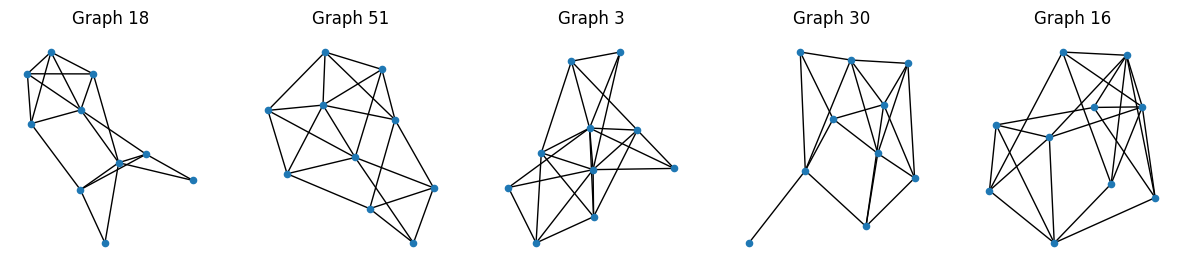

[Epoch 500/7000] D loss: 0.2077 | G loss: 3.2786 | Tree: 0/53


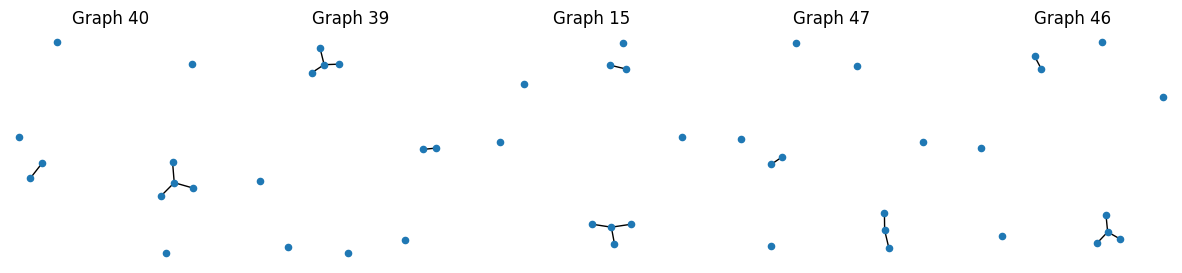

[Epoch 1000/7000] D loss: 0.2349 | G loss: 3.8259 | Tree: 0/53


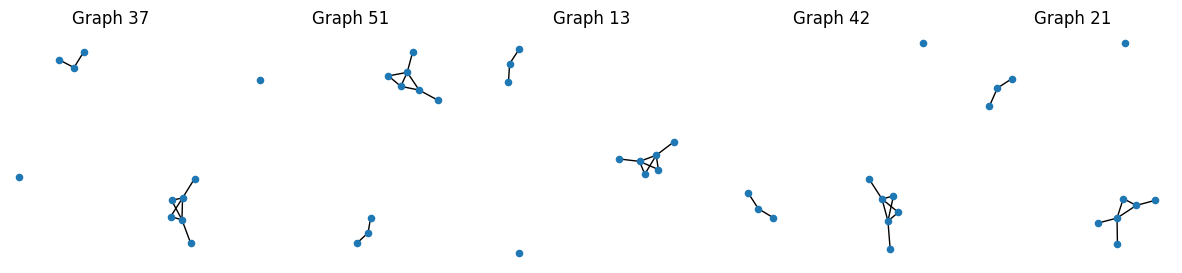

[Epoch 1500/7000] D loss: 0.2181 | G loss: 3.5939 | Tree: 8/53


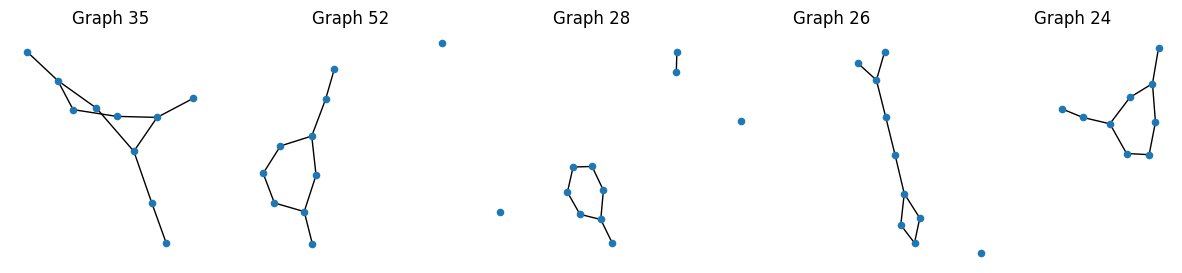

[Epoch 2000/7000] D loss: 0.1962 | G loss: 3.7502 | Tree: 4/53


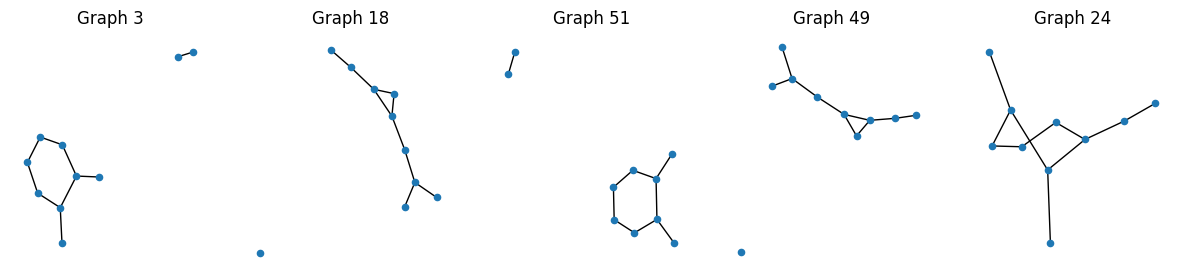

[Epoch 2500/7000] D loss: 0.2208 | G loss: 3.9181 | Tree: 11/53


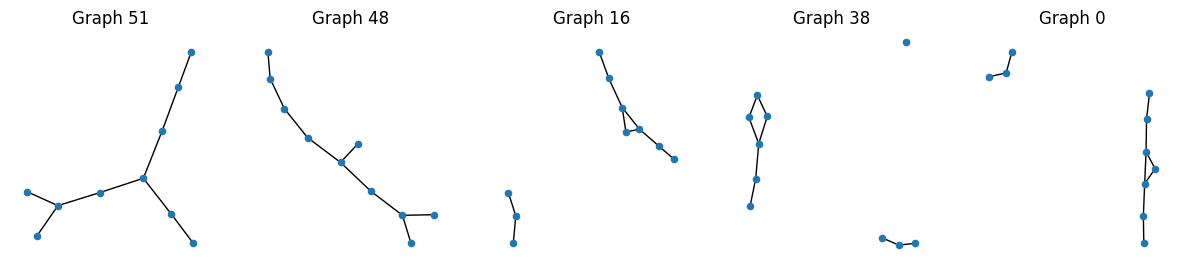

[Epoch 3000/7000] D loss: 0.1995 | G loss: 4.1083 | Tree: 7/53


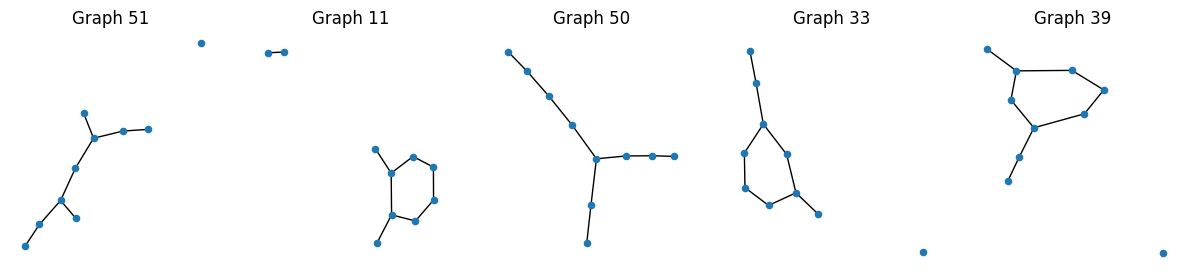

[Epoch 3500/7000] D loss: 0.2056 | G loss: 3.8980 | Tree: 2/53


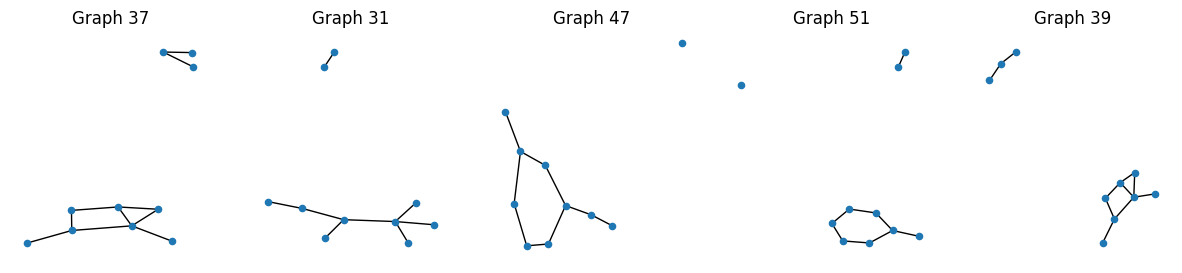

[Epoch 4000/7000] D loss: 0.2139 | G loss: 3.9360 | Tree: 0/53


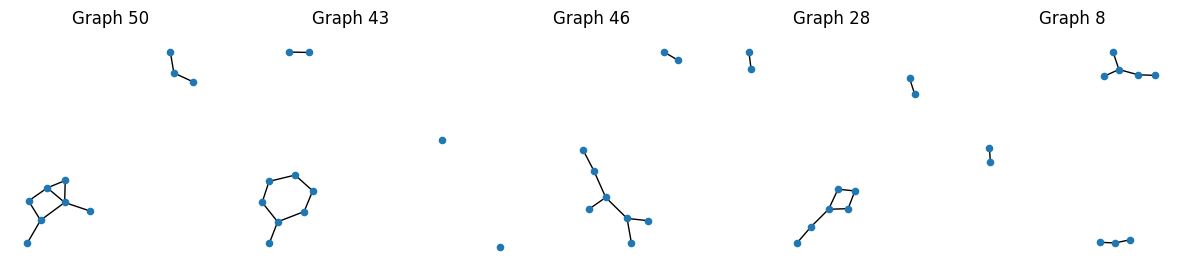

[Epoch 4500/7000] D loss: 0.2125 | G loss: 3.8752 | Tree: 13/53


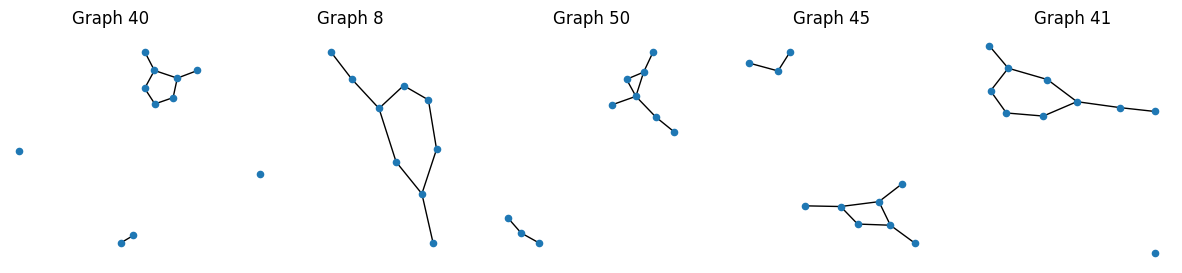

[Epoch 5000/7000] D loss: 0.2133 | G loss: 3.7192 | Tree: 0/53


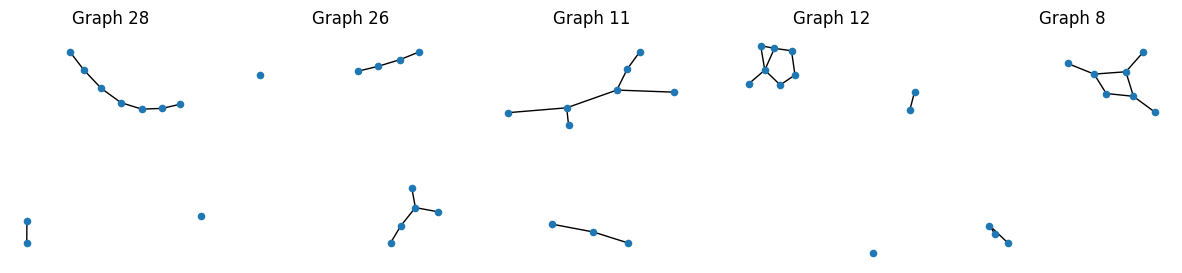

[Epoch 5500/7000] D loss: 0.2067 | G loss: 4.0654 | Tree: 0/53


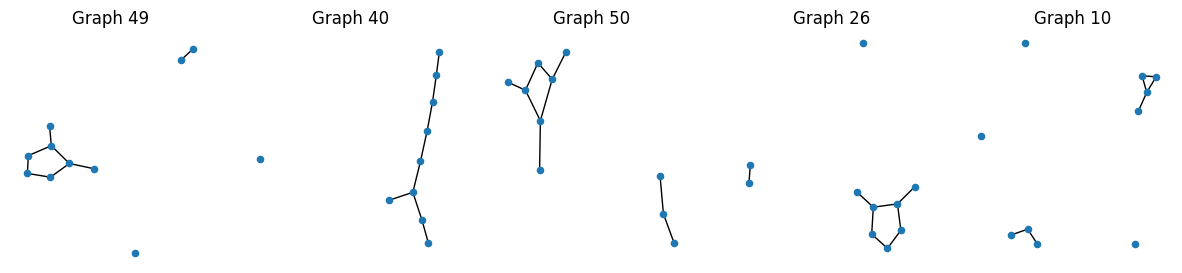

[Epoch 6000/7000] D loss: 0.2069 | G loss: 3.9552 | Tree: 0/53


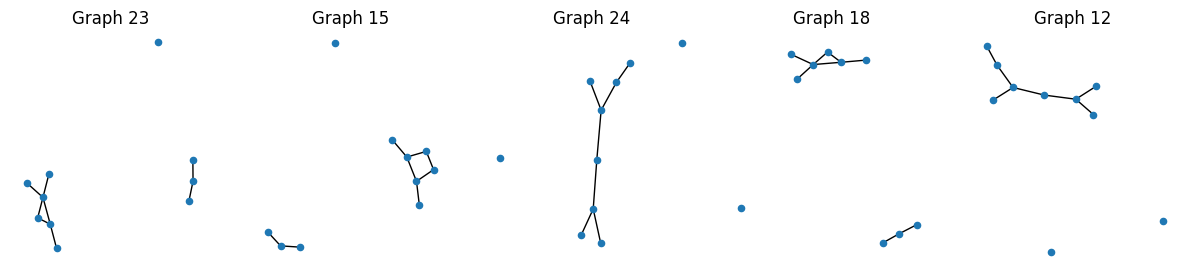

[Epoch 6500/7000] D loss: 0.2188 | G loss: 3.8701 | Tree: 0/53


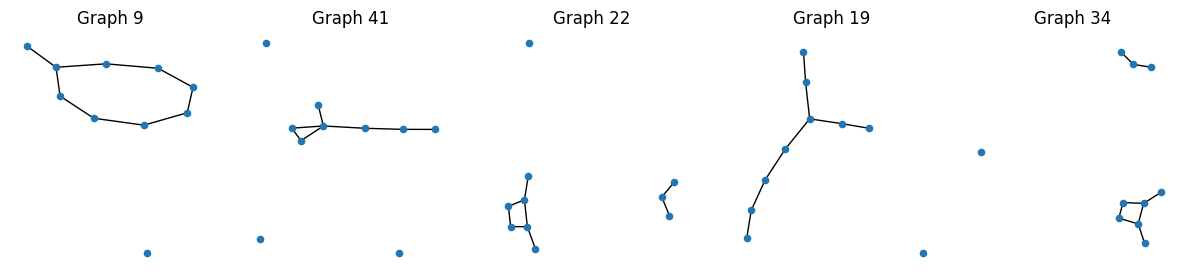

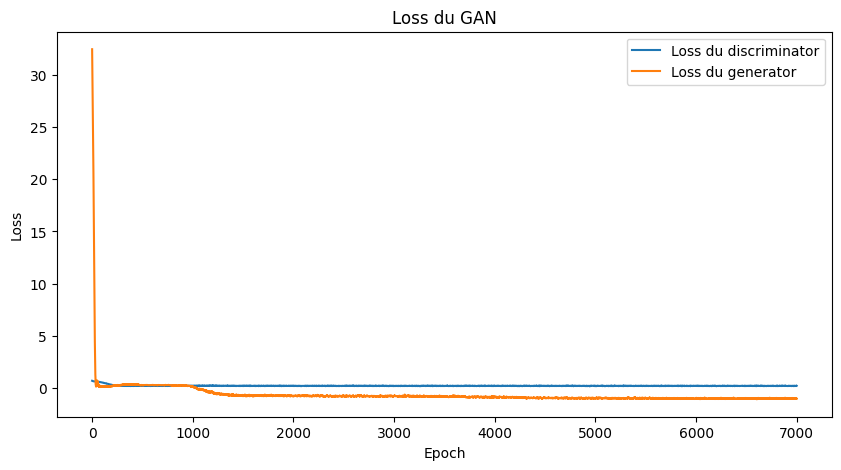

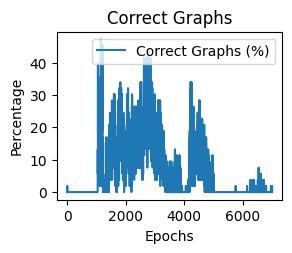

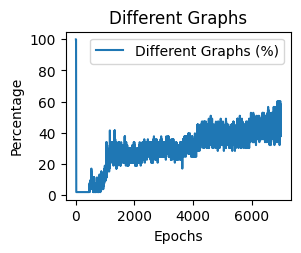


    Temps :  1016.2977101802826


'\ndef filter_and_resample(graphs, generator, latent_dim, threshold=0.9):\n    unique_graphs = []\n    z_replacement = torch.randn(len(graphs), latent_dim)\n    \n    for idx, g in enumerate(graphs):\n        if is_duplicate(g, unique_graphs, threshold):\n            new_graph = generator(z_replacement[idx].unsqueeze(0)).detach()\n            unique_graphs.append(new_graph)\n        else:\n            unique_graphs.append(g)\n    return torch.stack(unique_graphs)\n\ndef is_duplicate(graph, graph_list, threshold):\n    for g in graph_list:\n        if torch.norm(graph - g) < threshold:\n            return True\n    return False\n'

In [5]:
#from arbres import genere_tree_dataset, calculate_correct_graphs, calculate_different_graphs, adjacency, diversity_loss, edge_count_loss
#from scipy.sparse.csgraph import connected_components
'''
if os.path.exists('generated_graphs'):
    shutil.rmtree('generated_graphs')  # Supprime tout le dossier et son contenu
os.makedirs('generated_graphs', exist_ok=True)  # Recrée un répertoire vide
'''



# Le générateur (essaye de tromper le discriminateur)
class GraphGenerator(nn.Module):
    def __init__(self, n_nodes, latent_dim=10):
        super(GraphGenerator, self).__init__()
        self.n_nodes = n_nodes
        input_dim = n_nodes * n_nodes + latent_dim  # Inclure les conditions

        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, n_nodes * n_nodes),
            nn.Sigmoid()
        )

    def forward(self, z):
        flat_matrix = self.fc(z)
        adj_matrix = flat_matrix.view(-1, self.n_nodes, self.n_nodes)
        adj_matrix = (adj_matrix + adj_matrix.transpose(1, 2)) / 2
        adj_matrix = adj_matrix * (1 - torch.eye(self.n_nodes, device=adj_matrix.device).unsqueeze(0))
        return adj_matrix




class ConstrainedGraphGenerator(nn.Module):
    def __init__(self, n_nodes):
        super(ConstrainedGraphGenerator, self).__init__()
        self.n_nodes = n_nodes

        # Générateur de structure latente
        self.fc = nn.Sequential(
            nn.Linear(n_nodes * (n_nodes - 1) // 2, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, n_nodes * (n_nodes - 1) // 2),  # Génération d'arêtes dans un graphe connexe
            nn.Sigmoid()  # Normaliser entre 0 et 1
        )

    def forward(self, z):
        """
        Génère un graphe connexe avec exactement n-1 arêtes.

        Arguments :
        - z : Tensor (batch_size, latent_dim), vecteur latent.

        Retourne :
        - adj_matrix : Tensor (batch_size, n_nodes, n_nodes), matrices d'adjacence générées.
        """
        batch_size = z.size(0)
        n_nodes = self.n_nodes

        # Générer une liste aplatie des arêtes possibles (sans les diagonales)
        edge_weights_flat = self.fc(z)

        # Transformer les probabilités en arêtes binaires (seuil dynamique)
        edge_weights_binary = (edge_weights_flat > 0.5).float()

        # Reshape en une matrice triangulaire supérieure
        tril_indices = torch.tril_indices(n_nodes, n_nodes, offset=-1)
        adj_matrix = torch.zeros(batch_size, n_nodes, n_nodes, device=edge_weights_binary.device)

        for i in range(batch_size):
            # Insérer les arêtes générées dans la partie inférieure triangulaire
            adj_matrix[i][tril_indices[0], tril_indices[1]] = edge_weights_binary[i]

        # Rendre la matrice symétrique
        adj_matrix = adj_matrix + adj_matrix.transpose(1, 2)

        # Corriger pour garantir exactement n-1 arêtes et la connectivité
        adj_matrix = self._enforce_tree_constraints(adj_matrix)

        return adj_matrix

    def _enforce_tree_constraints(self, adj_matrix):
        """
        Ajuste la matrice d'adjacence pour s'assurer qu'elle représente un graphe connexe
        avec exactement n-1 arêtes.

        Arguments :
        - adj_matrix : Tensor (batch_size, n_nodes, n_nodes), matrices d'adjacence.

        Retourne :
        - adj_matrix : Tensor corrigée.
        """
        batch_size, n_nodes, _ = adj_matrix.size()

        for i in range(batch_size):
            # Convertir la matrice en graphe
            adj = adj_matrix[i].detach().cpu().numpy()
            adj_bin = (adj > 0.5).astype(int)

            # Corriger la connectivité avec l'algorithme de l'arbre couvrant minimal
            from scipy.sparse.csgraph import minimum_spanning_tree

            mst = minimum_spanning_tree(adj_bin)  # Obtenir un arbre couvrant
            mst = mst.toarray().astype(float)
            adj_matrix[i] = torch.tensor(mst, device=adj_matrix.device)

        return adj_matrix

# Discriminateur (Juge si une matrice d'adjacence est réelle ou générée)
#from torch_geometric.nn import GCNConv

class GraphDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super(GraphDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Probabilité que la matrice soit réelle
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Aplatir la matrice
        return self.model(x)

def wasserstein_loss(y_true, y_pred):
    return torch.mean(y_true * y_pred)  # y_true est 1 ou -1


def interpolate_and_generate(generator, z1, z2, steps):
    interpolated_graphs = []
    for alpha in torch.linspace(0, 1, steps):
        z = z1 * (1 - alpha) + z2 * alpha  # Interpolation linéaire
        generated_graph = generator(z.unsqueeze(0))
        interpolated_graphs.append(generated_graph.detach())
    return torch.cat(interpolated_graphs)
def diversity_metric(graph):
    """
    Mesure une métrique de diversité (à personnaliser).
    Exemple : Nombre d'arêtes, variance des connexions.
    """
    adj_matrix = graph.squeeze().numpy()
    unique_edges = np.unique(adj_matrix > 0.5)  # Seulement les arêtes
    return len(unique_edges) / (adj_matrix.shape[0] ** 2)

#
def resample_generated_graphs(graphs):
    """
    Ré-échantillonne les graphes pour encourager la diversité.
    :param graphs: Tensor des graphes générés (batch_size, n_nodes, n_nodes)
    :return: Tensor des graphes ré-échantillonnés
    """
    resampled = []
    for graph in graphs:
        # Appliquer une perturbation sur chaque graphe
        perturbed_graph = graph + 0.1 * torch.randn_like(graph)
        perturbed_graph = torch.clamp(perturbed_graph, 0, 1)  # Normaliser entre 0 et 1

        # Ajouter un critère de diversité (par ex., conserver des graphes avec des cycles spécifiques)
        if torch.sum(perturbed_graph) > 0.5 * graph.numel():  # Critère arbitraire
            resampled.append(perturbed_graph)
        else:
            resampled.append(graph)

    return torch.stack(resampled)

def generate_conditional_noise(batch_size, n_nodes, condition_dim=10):
    """
    Génère un bruit conditionné en fonction de conditions spécifiques.
    :param batch_size: Taille du lot.
    :param n_nodes: Nombre de nœuds dans le graphe.
    :param condition_dim: Dimension de l'information conditionnelle.
    :return: Tensor de bruit conditionné.
    """
    noise = torch.randn(batch_size, n_nodes * n_nodes)  # Bruit aléatoire
    conditions = torch.randn(batch_size, condition_dim)  # Conditions aléatoires (ou basées sur des données spécifiques)

    # Combiner le bruit et les conditions
    conditional_noise = torch.cat((noise, conditions), dim=1)
    return conditional_noise



'''####
def tree_loss(adj_matrix):
    connectivity = torch.zeros(adj_matrix.size(0)).to(adj_matrix.device)

    matrice = (adj_matrix>0.5).float() + adj_matrix - adj_matrix.detach()
    for i in range(adj_matrix.size(0)):


        G = nx.from_numpy_array(matrice[i].detach().cpu().numpy())
        num_components = nx.number_connected_components(G)

        connectivity[i] = num_components

    loss_connexe = torch.sum((connectivity-1)**2)

    degrees = torch.sum(adj_matrix, dim=2)
    somme_deg=torch.sum(degrees,dim=1)
    somme_deg_loss=torch.sum(torch.sum((somme_deg-2*(n_nodes-1))**2,dim=0))

    return loss_connexe + somme_deg_loss, loss_connexe
'''

def lossConnexe1(fake_graphs):
    batch_size, n_nodes, _ = fake_graphs.size()
    loss = 0.

    for adj in fake_graphs:
        adj_bin = (adj.detach().cpu().numpy() > 0.5).astype(int)
        G = nx.from_numpy_array(adj_bin)
        components = nx.connected_components(G)

        for component in components:
            if len(component) == 1:
                loss+=1  # Il y a une composante singleton
                break
    return loss/ batch_size

def degree_loss(fake_graphs):
    batch_size, n_nodes, _ = fake_graphs.size()
    loss = 0.

    for adj in fake_graphs:
        adj_bin = (adj.detach().cpu().numpy() > 0.5).astype(int)
        G = nx.from_numpy_array(adj_bin)
        if 0 in G.degree:
            loss+=1
    return loss/batch_size

def train(n_nodes=10, num_epochs=10_000, batch_size=32):
    """
    Entraîne un GAN pour générer des graphes.

    Args:
        n_nodes (int): Nombre de sommets, 10 par défaut.
        num_epochs (int): Nombre d'époques pour l'entraînement, 10_000 par défaut.
        batch_size (int): Taille des lots pour l'entraînement, 32 par défaut.
    """


    adj_matrix_dim = n_nodes * n_nodes  # Représentation sous forme de matrice d'adjacence

    # Créer les modèles
    generator = GraphGenerator(n_nodes=n_nodes, latent_dim=n_nodes)
    discriminator = GraphDiscriminator(input_dim=adj_matrix_dim)

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
    #scheduler_G = optim.lr_scheduler.ExponentialLR(g_optimizer, gamma=0.9)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.00013)


    #loss_fn = tree_loss
    loss_fn = nn.BCELoss()
    #loss_fn  = wasserstein_loss

    graph_dataset = np.array([adjacency(g) for g in genere_tree_dataset(n_nodes,c=50)])
    n_graphs=len(graph_dataset)
    rd.shuffle(graph_dataset)
    graph_dataset = graph_dataset.reshape(n_graphs, -1)
    # Enregistrer les graphes dans le dataset
    #save_graphs(graph_dataset, n_graphs, n_nodes)

    d_losses = []
    g_losses = []

    correct_graph_percentages = []
    different_graph_percentages = []

    # Boucle d'entraînement principale
    for epoch in range(num_epochs):
        # Étape 1: Entraîner le Discriminateur avec des graphes réels et générés
        '''
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        real_labels = torch.full((batch_size, 1), 0.9)
        fake_labels = torch.zeros(batch_size, 1)
        '''
        #scheduler_G.step()

        real_labels = torch.clamp(torch.full((batch_size, 1), 0.9) + 0.05 * torch.randn(batch_size, 1), 0, 1)# Smoothing des labels réels et ajout d'un bruit aléatoire sur les labels pour augmenter la robustesse du modèle
        fake_labels = torch.clamp(0.05 * torch.randn(batch_size, 1), 0, 1)




        if epoch%2==0:
            d_optimizer.zero_grad()

            z = generate_conditional_noise(batch_size, n_nodes) # Bruit aléatoire pour le générateur
            fake_graphs = generator(z)


            idx = np.random.randint(0, n_graphs, batch_size)
            real_graphs = torch.tensor(graph_dataset[idx], dtype=torch.float32)
            real_loss = loss_fn(discriminator(real_graphs), real_labels)
            fake_loss = loss_fn(discriminator(fake_graphs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss)/2
            d_loss.backward()
            d_optimizer.step()


        # Étape 2: Entraîner le Générateur pour tromper le Discriminateur
        g_optimizer.zero_grad()
        z = generate_conditional_noise(batch_size, n_nodes)  # Bruit aléatoire pour le générateur
        fake_graphs = generator(z)

        # *** Ré-échantillonnage ***
        sampled_graphs = resample_generated_graphs(fake_graphs)

        generated_loss = loss_fn(discriminator(sampled_graphs), torch.ones(batch_size, 1))  # Le générateur essaie de tromper le discriminateur


        total_loss = 0.1*generated_loss+ + 1.7*degree_loss(fake_graphs)+ 0.7 * diversity_loss(fake_graphs)  +0.18 * edge_count_loss(fake_graphs, n_nodes) #0.1*cycles_loss(fake_graphs)#
        total_loss.backward()
        g_optimizer.step()

        d_losses.append(d_loss.item())
        g_losses.append(total_loss.item())



        # Stocker les métriques
        correct_graph_percentages.append(calculate_correct_graphs(fake_graphs.detach().numpy()))
        different_graph_percentages.append(calculate_different_graphs(fake_graphs.detach().numpy()))
        '''
        for adj in fake_graphs.detach().numpy():
            if is_valid_tree(adj, n_nodes):
                nx.draw(nx.from_numpy_array(adj))
                plt.title(f"Arbre et un vrai ! {epoch}")
        '''

        # Afficher la loss toutes les 500 époques
        if epoch % 500 == 0:
            '''
            print(f"Epoch [{epoch}/{num_epochs}], Loss D: {d_loss.item()}, Loss G: {total_loss.item()}")


            generated_adj_matrix = fake_graphs[0].detach().numpy()
            threshold = 0.5
            binary_adj_matrix = (generated_adj_matrix > threshold).astype(int)

            G = nx.from_numpy_array(binary_adj_matrix)

            try:
                cycles=nx.cycle_basis(G)



                if nx.is_tree(G): # Vérifie si le graphe est un arbre
                    dessiner(G)
                    plt.title(f"Arbre {epoch}")

                elif not cycles:
                    nx.draw(G,with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                    plt.title(f"Acyclique, pas arbre {epoch}")

                elif ((set(cycles[0])==set(G.nodes)) and (len(cycles)==1)):# Vérifie si un gaphe est un graphe-cycle.
                    pos = nx.kamada_kawai_layout(G) # For draw like a regular polygon
                    nx.draw(G,pos, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                    plt.title(f"Graphe-cycle {epoch}")

                else:
                    nx.draw_planar(G, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                    plt.title(f"Planaire quelquonque {epoch}")


            except nx.NetworkXException:
                # Si le graphe n'est pas planaire, utiliser un autre layout
                nx.draw(G,with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                plt.title(f"Quelquonque {epoch}")
            finally:
                plt.show()
                plt.close()
                '''
            tree_count = 0
            threshold = 0.5
            for graph in fake_graphs.detach().numpy():
                binary_matrix = (graph > threshold).astype(int)
                G = nx.from_numpy_array(binary_matrix)
                if nx.is_tree(G):
                    tree_count += 1

            print(f"[Epoch {epoch}/{num_epochs}] D loss: {d_loss.item():.4f} | "
                  f"G loss: {generated_loss.item():.4f} | Tree: {tree_count}/{batch_size}")

            # Affichage des graphes
            fig, axes = plt.subplots(1, 5, figsize=(15, 3))
            sample_indices = np.random.choice(fake_graphs.shape[0], 5, replace=False)
            for i, ax in zip(sample_indices, axes):
                binary_matrix = (fake_graphs[i].detach().numpy() > threshold).astype(int)
                G = nx.from_numpy_array(binary_matrix)
                nx.draw(G, ax=ax, node_size=20, font_size=8)
                ax.set_title(f"Graph {i}")
            plt.show()



    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Loss du discriminator')
    plt.plot(g_losses, label='Loss du generator')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss du GAN')
    plt.show()

    # Plot du pourcentage de graphes corrects
    plt.subplot(2, 2, 2)
    plt.plot(correct_graph_percentages, label="Correct Graphs (%)")
    plt.title("Correct Graphs")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()

    # Plot du pourcentage de graphes différents
    plt.subplot(2, 2, 3)
    plt.plot(different_graph_percentages, label="Different Graphs (%)")
    plt.title("Different Graphs")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()

d = time.time()
train(n_nodes=10, num_epochs=7_000, batch_size=53)
f = time.time()
duree = f - d
print("\n    Temps : ", duree)

'''
def filter_and_resample(graphs, generator, latent_dim, threshold=0.9):
    unique_graphs = []
    z_replacement = torch.randn(len(graphs), latent_dim)

    for idx, g in enumerate(graphs):
        if is_duplicate(g, unique_graphs, threshold):
            new_graph = generator(z_replacement[idx].unsqueeze(0)).detach()
            unique_graphs.append(new_graph)
        else:
            unique_graphs.append(g)
    return torch.stack(unique_graphs)

def is_duplicate(graph, graph_list, threshold):
    for g in graph_list:
        if torch.norm(graph - g) < threshold:
            return True
    return False
'''

##AB

In [12]:
def genere_binary_tree_dataset(n,c):
    '''
     Génère un dataset d'arbres binaires à n sommets où il y a un même nombre
     d'arbres binaires isomorphes entre eux pour chaque ensemble d'arbres binaires non isomorphes.

         En gros ; génère un dataset avec toute les sortes d' arbre binaire qui apparraissent c fois chacune

     Entier -> Liste de Graphes
    '''
    labeled_trees = nx.nonisomorphic_trees(n)
    dataset_0=list(labeled_trees)

    dataset_1 = []

    for tree in dataset_0:
      if is_binary_tree_fromGraph(tree):# L'admet que si il est binaire
        dataset_1.append(tree)

    dataset_2 = []

    for tree in dataset_1:
      for _ in range(c):
        tree_copy = random_isomorph_graph_from(tree)
        dataset_2.append(tree_copy)

    return dataset_2

def is_binary_tree_fromGraph(G):
    """
    Vérifie si un graphe est un arbre binaire valide.

    Graphe -> Bool
    """

    # Vérifier les degrés des nœuds
    for _, degree in G.degree():
        if degree > 3:  # Cette propriété suffit pour vérifier qu'un arbre est un arbre binaire
            return False

    return nx.is_tree(G)


<ipython-input-4-a2948f37a50e>:34: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  unique_graphs.add(binary_matrix.tostring())  # Représentation unique


[Epoch 0/5000] D loss: 0.6833 | G loss: 0.7314 | Tree: 0/53


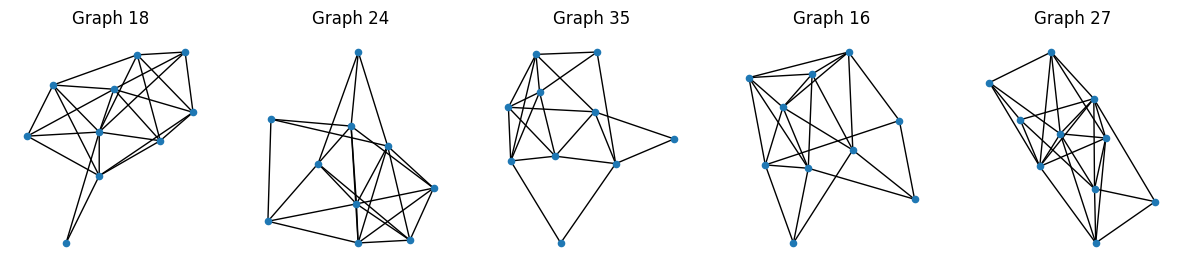

[Epoch 500/5000] D loss: 0.2156 | G loss: 3.2932 | Tree: 0/53


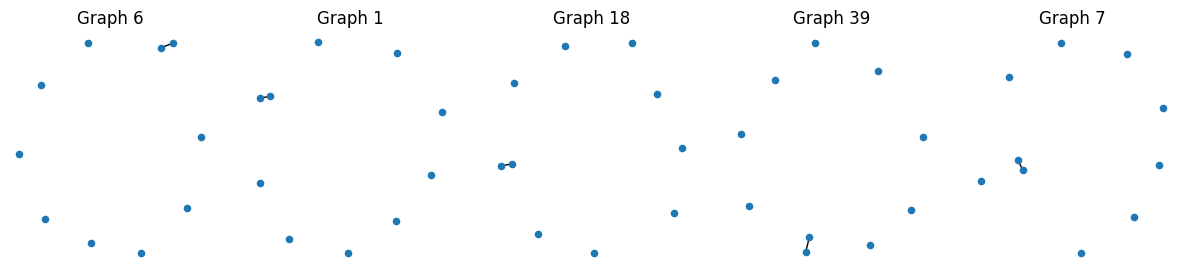

[Epoch 1000/5000] D loss: 0.2328 | G loss: 3.1177 | Tree: 0/53


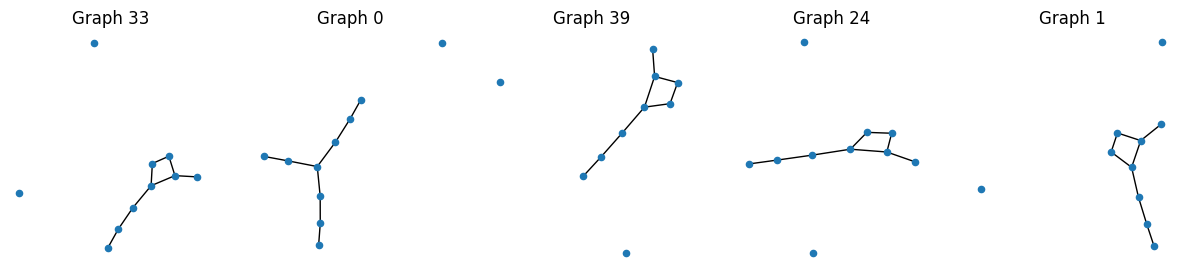

[Epoch 1500/5000] D loss: 0.2152 | G loss: 3.6755 | Tree: 24/53


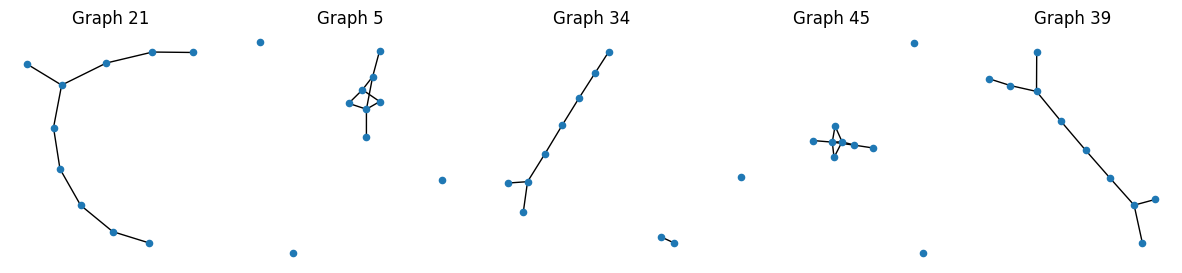

[Epoch 2000/5000] D loss: 0.2070 | G loss: 3.7579 | Tree: 8/53


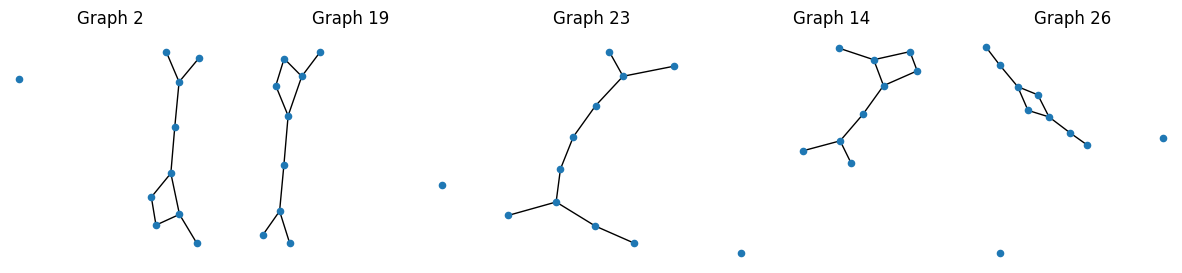

[Epoch 2500/5000] D loss: 0.2131 | G loss: 4.0393 | Tree: 11/53


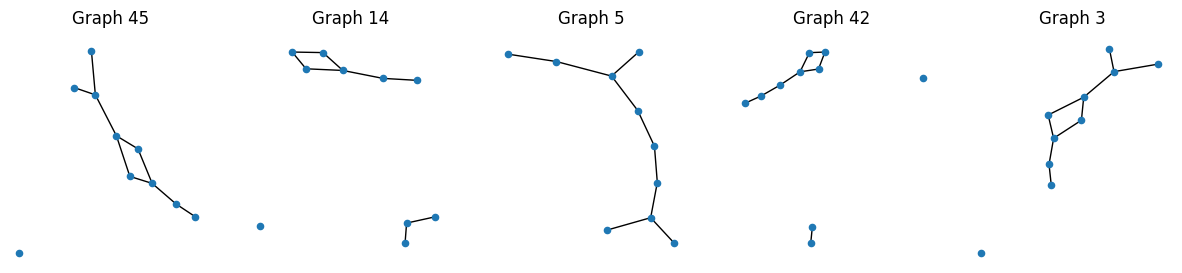

[Epoch 3000/5000] D loss: 0.2299 | G loss: 3.9580 | Tree: 4/53


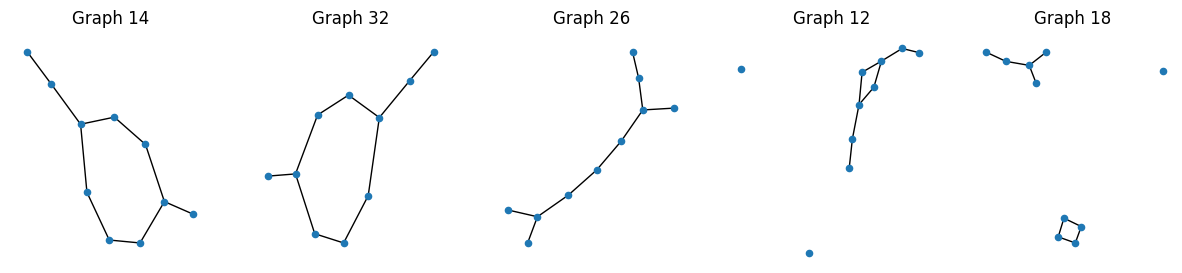

[Epoch 3500/5000] D loss: 0.2178 | G loss: 4.0065 | Tree: 4/53


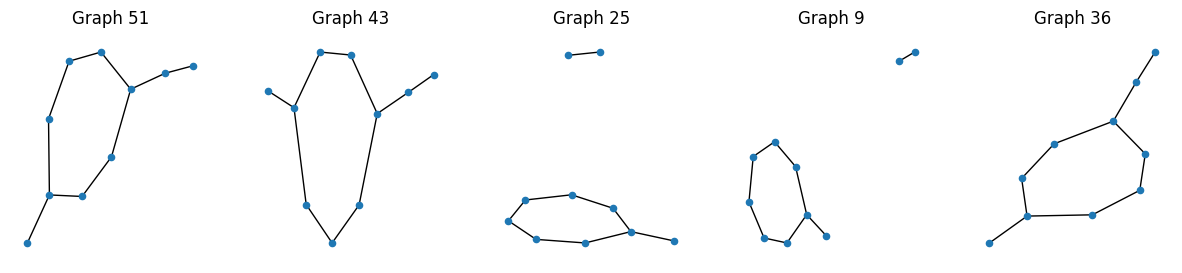

[Epoch 4000/5000] D loss: 0.2098 | G loss: 4.0886 | Tree: 3/53


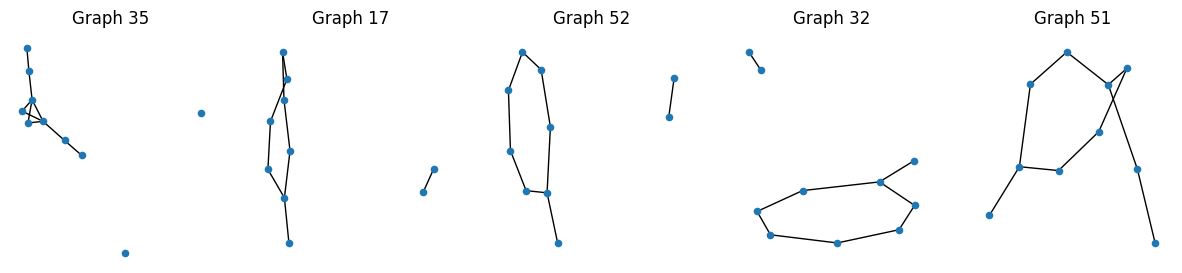

[Epoch 4500/5000] D loss: 0.2222 | G loss: 4.0231 | Tree: 4/53


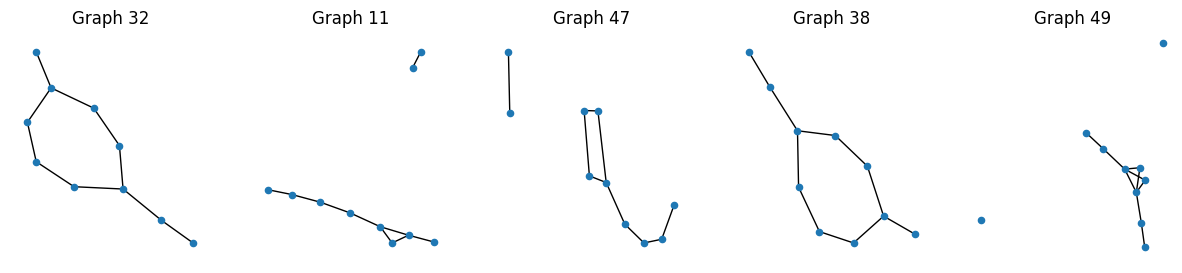

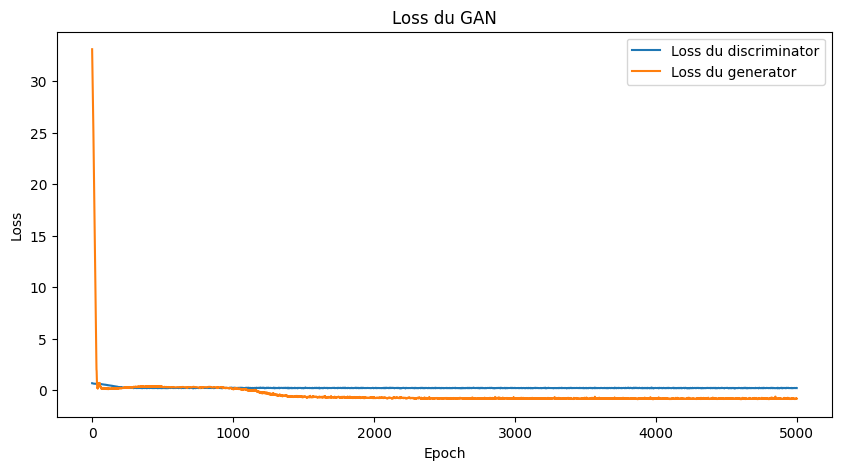

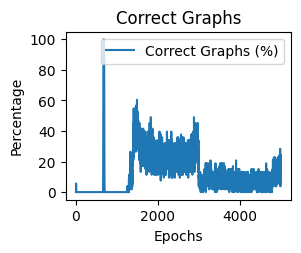

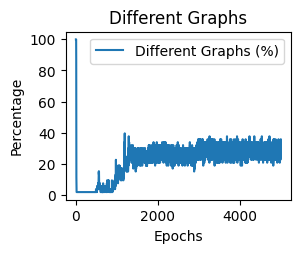


    Temps :  735.342887878418


'\ndef filter_and_resample(graphs, generator, latent_dim, threshold=0.9):\n    unique_graphs = []\n    z_replacement = torch.randn(len(graphs), latent_dim)\n    \n    for idx, g in enumerate(graphs):\n        if is_duplicate(g, unique_graphs, threshold):\n            new_graph = generator(z_replacement[idx].unsqueeze(0)).detach()\n            unique_graphs.append(new_graph)\n        else:\n            unique_graphs.append(g)\n    return torch.stack(unique_graphs)\n\ndef is_duplicate(graph, graph_list, threshold):\n    for g in graph_list:\n        if torch.norm(graph - g) < threshold:\n            return True\n    return False\n'

In [13]:
def train(n_nodes=10, num_epochs=10_000, batch_size=32):
    """
    Entraîne un GAN pour générer des graphes.

    Args:
        n_nodes (int): Nombre de sommets, 10 par défaut.
        num_epochs (int): Nombre d'époques pour l'entraînement, 10_000 par défaut.
        batch_size (int): Taille des lots pour l'entraînement, 32 par défaut.
    """


    adj_matrix_dim = n_nodes * n_nodes  # Représentation sous forme de matrice d'adjacence

    # Créer les modèles
    generator = GraphGenerator(n_nodes=n_nodes, latent_dim=n_nodes)
    discriminator = GraphDiscriminator(input_dim=adj_matrix_dim)

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
    #scheduler_G = optim.lr_scheduler.ExponentialLR(g_optimizer, gamma=0.9)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.00013)


    #loss_fn = tree_loss
    loss_fn = nn.BCELoss()
    #loss_fn  = wasserstein_loss

    graph_dataset = np.array([adjacency(g) for g in genere_binary_tree_dataset(n_nodes,c=50)])
    n_graphs=len(graph_dataset)
    rd.shuffle(graph_dataset)
    graph_dataset = graph_dataset.reshape(n_graphs, -1)
    # Enregistrer les graphes dans le dataset
    #save_graphs(graph_dataset, n_graphs, n_nodes)

    d_losses = []
    g_losses = []

    correct_graph_percentages = []
    different_graph_percentages = []

    # Boucle d'entraînement principale
    for epoch in range(num_epochs):
        # Étape 1: Entraîner le Discriminateur avec des graphes réels et générés
        '''
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        real_labels = torch.full((batch_size, 1), 0.9)
        fake_labels = torch.zeros(batch_size, 1)
        '''
        #scheduler_G.step()

        real_labels = torch.clamp(torch.full((batch_size, 1), 0.9) + 0.05 * torch.randn(batch_size, 1), 0, 1)# Smoothing des labels réels et ajout d'un bruit aléatoire sur les labels pour augmenter la robustesse du modèle
        fake_labels = torch.clamp(0.05 * torch.randn(batch_size, 1), 0, 1)




        if epoch%2==0:
            d_optimizer.zero_grad()

            z = generate_conditional_noise(batch_size, n_nodes) # Bruit aléatoire pour le générateur
            fake_graphs = generator(z)


            idx = np.random.randint(0, n_graphs, batch_size)
            real_graphs = torch.tensor(graph_dataset[idx], dtype=torch.float32)
            real_loss = loss_fn(discriminator(real_graphs), real_labels)
            fake_loss = loss_fn(discriminator(fake_graphs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss)/2
            d_loss.backward()
            d_optimizer.step()


        # Étape 2: Entraîner le Générateur pour tromper le Discriminateur
        g_optimizer.zero_grad()
        z = generate_conditional_noise(batch_size, n_nodes)  # Bruit aléatoire pour le générateur
        fake_graphs = generator(z)

        # *** Ré-échantillonnage ***
        sampled_graphs = resample_generated_graphs(fake_graphs)

        generated_loss = loss_fn(discriminator(sampled_graphs), torch.ones(batch_size, 1))  # Le générateur essaie de tromper le discriminateur


        total_loss = 0.1*generated_loss+ + 1.7*degree_loss(fake_graphs)+ 0.7 * diversity_loss(fake_graphs)  +0.18 * edge_count_loss(fake_graphs, n_nodes) #0.1*cycles_loss(fake_graphs)#
        total_loss.backward()
        g_optimizer.step()

        d_losses.append(d_loss.item())
        g_losses.append(total_loss.item())



        # Stocker les métriques
        correct_graph_percentages.append(calculate_correct_graphs(fake_graphs.detach().numpy(), fct = is_binary_tree_fromGraph))
        different_graph_percentages.append(calculate_different_graphs(fake_graphs.detach().numpy()))
        '''
        for adj in fake_graphs.detach().numpy():
            if is_valid_tree(adj, n_nodes):
                nx.draw(nx.from_numpy_array(adj))
                plt.title(f"Arbre et un vrai ! {epoch}")
        '''

        # Afficher la loss toutes les 500 époques
        if epoch % 500 == 0:
            '''
            print(f"Epoch [{epoch}/{num_epochs}], Loss D: {d_loss.item()}, Loss G: {total_loss.item()}")


            generated_adj_matrix = fake_graphs[0].detach().numpy()
            threshold = 0.5
            binary_adj_matrix = (generated_adj_matrix > threshold).astype(int)

            G = nx.from_numpy_array(binary_adj_matrix)

            try:
                cycles=nx.cycle_basis(G)



                if nx.is_tree(G): # Vérifie si le graphe est un arbre
                    dessiner(G)
                    plt.title(f"Arbre {epoch}")

                elif not cycles:
                    nx.draw(G,with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                    plt.title(f"Acyclique, pas arbre {epoch}")

                elif ((set(cycles[0])==set(G.nodes)) and (len(cycles)==1)):# Vérifie si un gaphe est un graphe-cycle.
                    pos = nx.kamada_kawai_layout(G) # For draw like a regular polygon
                    nx.draw(G,pos, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                    plt.title(f"Graphe-cycle {epoch}")

                else:
                    nx.draw_planar(G, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                    plt.title(f"Planaire quelquonque {epoch}")


            except nx.NetworkXException:
                # Si le graphe n'est pas planaire, utiliser un autre layout
                nx.draw(G,with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
                plt.title(f"Quelquonque {epoch}")
            finally:
                plt.show()
                plt.close()
                '''
            tree_count = 0
            threshold = 0.5
            for graph in fake_graphs.detach().numpy():
                binary_matrix = (graph > threshold).astype(int)
                G = nx.from_numpy_array(binary_matrix)
                if nx.is_tree(G):
                    tree_count += 1

            print(f"[Epoch {epoch}/{num_epochs}] D loss: {d_loss.item():.4f} | "
                  f"G loss: {generated_loss.item():.4f} | Tree: {tree_count}/{batch_size}")

            # Affichage des graphes
            fig, axes = plt.subplots(1, 5, figsize=(15, 3))
            sample_indices = np.random.choice(fake_graphs.shape[0], 5, replace=False)
            for i, ax in zip(sample_indices, axes):
                binary_matrix = (fake_graphs[i].detach().numpy() > threshold).astype(int)
                G = nx.from_numpy_array(binary_matrix)
                nx.draw(G, ax=ax, node_size=20, font_size=8)
                ax.set_title(f"Graph {i}")
            plt.show()



    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Loss du discriminator')
    plt.plot(g_losses, label='Loss du generator')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss du GAN')
    plt.show()

    # Plot du pourcentage de graphes corrects
    plt.subplot(2, 2, 2)
    plt.plot(correct_graph_percentages, label="Correct Graphs (%)")
    plt.title("Correct Graphs")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()

    # Plot du pourcentage de graphes différents
    plt.subplot(2, 2, 3)
    plt.plot(different_graph_percentages, label="Different Graphs (%)")
    plt.title("Different Graphs")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()

d = time.time()
train(n_nodes=10, num_epochs=5_000, batch_size=53)
f = time.time()
duree = f - d
print("\n    Temps : ", duree)

'''
def filter_and_resample(graphs, generator, latent_dim, threshold=0.9):
    unique_graphs = []
    z_replacement = torch.randn(len(graphs), latent_dim)

    for idx, g in enumerate(graphs):
        if is_duplicate(g, unique_graphs, threshold):
            new_graph = generator(z_replacement[idx].unsqueeze(0)).detach()
            unique_graphs.append(new_graph)
        else:
            unique_graphs.append(g)
    return torch.stack(unique_graphs)

def is_duplicate(graph, graph_list, threshold):
    for g in graph_list:
        if torch.norm(graph - g) < threshold:
            return True
    return False
'''